<a href="https://colab.research.google.com/github/ArnavK04/PH354-Assignments/blob/main/Kumar_Arnav_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Question - 1**

**Q.1 (a)**

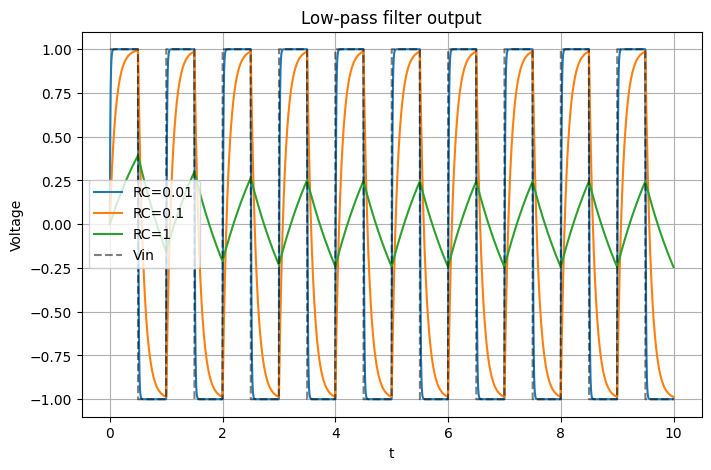

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# square wave input
def Vin(t):
    if int(np.floor(2*t)) % 2 == 0:
        return 1
    else:
        return -1

def f(t, Vout, RC):
    return (Vin(t) - Vout)/RC

def solve(RC, h=0.001, tmax=10):

    t = np.arange(0, tmax, h)
    Vout = np.zeros(len(t))

    for i in range(len(t)-1):

        k1 = h * f(t[i], Vout[i], RC)
        k2 = h * f(t[i] + h/2, Vout[i] + k1/2, RC)
        k3 = h * f(t[i] + h/2, Vout[i] + k2/2, RC)
        k4 = h * f(t[i] + h, Vout[i] + k3, RC)

        Vout[i+1] = Vout[i] + (k1 + 2*k2 + 2*k3 + k4)/6

    return t, Vout

RC_values = [0.01, 0.1, 1]

plt.figure(figsize=(8,5))

for RC in RC_values:
    t, Vout = solve(RC)
    plt.plot(t, Vout, label=f"RC={RC}")

t = np.arange(0,10,0.001)
plt.plot(t, [Vin(x) for x in t], 'k--', alpha=0.5, label="Vin")

plt.xlabel("t")
plt.ylabel("Voltage")
plt.legend()
plt.grid(which='both', axis='both')
plt.title("Low-pass filter output")
plt.show()

**Q.1 (b)** It can be seen that for lower valuesof RC, $V_{out}$ is very similar to the square wave. But for higher values of RC, the output deviates more from the square wave and the voltage changes more slowly (at a lower frequency). This is because square contains a lot of higher frequency componenets. For low values of RC, the filtering is weak hence $V{out}$ is similar to $V_{in}$. For lower values of RC, filtering is more effective and hence only the lower frequencies remain in $V_{out}$.

# **Question - 2**

**Q.2 (a)**

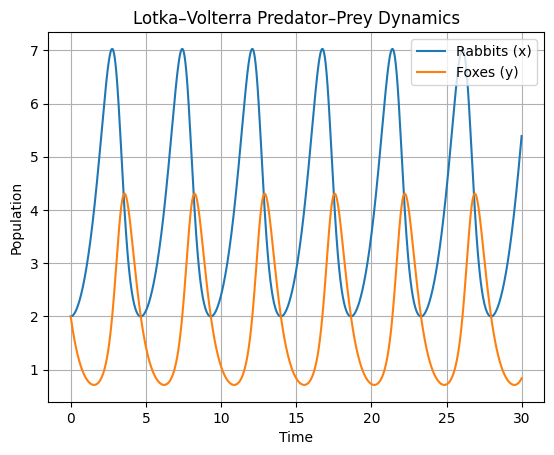

In [109]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 1
beta = 0.5
gamma = 0.5
delta = 2

# derivatives
def f(t, x, y):
    dxdt = alpha*x - beta*x*y
    dydt = gamma*x*y - delta*y
    return dxdt, dydt

def solve(h=0.01, tmax=30):

    t = np.arange(0, tmax, h)

    x = np.zeros(len(t))
    y = np.zeros(len(t))

    x[0] = 2
    y[0] = 2

    for i in range(len(t)-1):

        k1x, k1y = f(t[i], x[i], y[i])

        k2x, k2y = f(t[i]+h/2,
                     x[i] + h*k1x/2,
                     y[i] + h*k1y/2)

        k3x, k3y = f(t[i]+h/2,
                     x[i] + h*k2x/2,
                     y[i] + h*k2y/2)

        k4x, k4y = f(t[i]+h,
                     x[i] + h*k3x,
                     y[i] + h*k3y)

        x[i+1] = x[i] + h*(k1x + 2*k2x + 2*k3x + k4x)/6
        y[i+1] = y[i] + h*(k1y + 2*k2y + 2*k3y + k4y)/6

    return t, x, y

t, x, y = solve()

plt.plot(t, x, label="Rabbits (x)")
plt.plot(t, y, label="Foxes (y)")

plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.grid(which='both', axis='both')
plt.title("Lotka–Volterra Predator–Prey Dynamics")
plt.show()

**Q.2 (b)** Initially, with only a moderate number of foxes, rabbits reproduce faster than they are eaten, so x rises sharply. Then the abundance of prey gives foxes plenty of food; y climbs steeply, lagging behind the rabbit peak. The now-large fox population eats rabbits far faster than they can reproduce; x plummets. Then starved of prey, foxes die of old age faster than they can breed; y collapses back toward its starting value.

This cycle repeats again.


The feautre is that the predator numbers decline or rise only after the prey numbers, after a lag that is.

#  **Question - 3**

**Q.3 (a)**

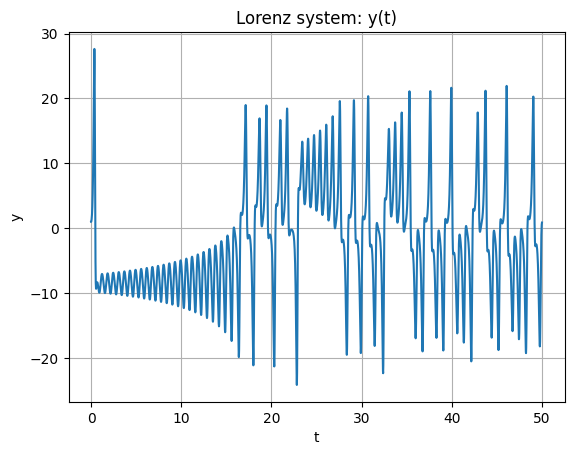

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
sigma = 10
r = 28
b = 8/3

# Lorenz equations
def f(t, x, y, z):
    dx = sigma*(y-x)
    dy = r*x - y - x*z
    dz = x*y - b*z
    return dx, dy, dz

# RK4 solver
def solve(h=0.01, tmax=50):

    t = np.arange(0, tmax, h)

    x = np.zeros(len(t))
    y = np.zeros(len(t))
    z = np.zeros(len(t))

    x[0], y[0], z[0] = 0, 1, 0

    for i in range(len(t)-1):

        k1x, k1y, k1z = f(t[i], x[i], y[i], z[i])

        k2x, k2y, k2z = f(t[i]+h/2,
                          x[i]+h*k1x/2,
                          y[i]+h*k1y/2,
                          z[i]+h*k1z/2)

        k3x, k3y, k3z = f(t[i]+h/2,
                          x[i]+h*k2x/2,
                          y[i]+h*k2y/2,
                          z[i]+h*k2z/2)

        k4x, k4y, k4z = f(t[i]+h,
                          x[i]+h*k3x,
                          y[i]+h*k3y,
                          z[i]+h*k3z)

        x[i+1] = x[i] + h*(k1x+2*k2x+2*k3x+k4x)/6
        y[i+1] = y[i] + h*(k1y+2*k2y+2*k3y+k4y)/6
        z[i+1] = z[i] + h*(k1z+2*k2z+2*k3z+k4z)/6

    return t, x, y, z


t, x, y, z = solve()

# plot y vs time
plt.plot(t, y)
plt.xlabel("t")
plt.ylabel("y")
plt.grid(which='both',axis='both')
plt.title("Lorenz system: y(t)")
plt.show()

**Q.3 (b)** Run part (a) first

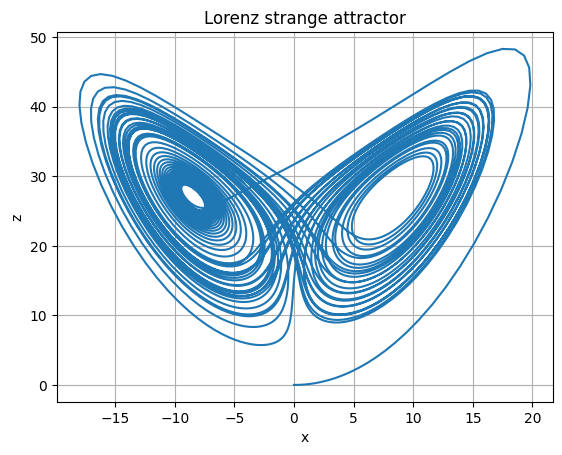

In [111]:
plt.plot(x, z)
plt.xlabel("x")
plt.ylabel("z")
plt.grid(which='both',axis='both')
plt.title("Lorenz strange attractor")
plt.show()

# **Question - 4**

**Q.4 (a)** We can convert the second order equation in to 2 first order equations and then solve them as before with RK4

Let $\frac{dx}{dt} = v$

$\therefore \frac{dv}{dt} = -\omega^2 x $

The above two equations can be solve with RK4. The initial conditions are x = 1, v = 0

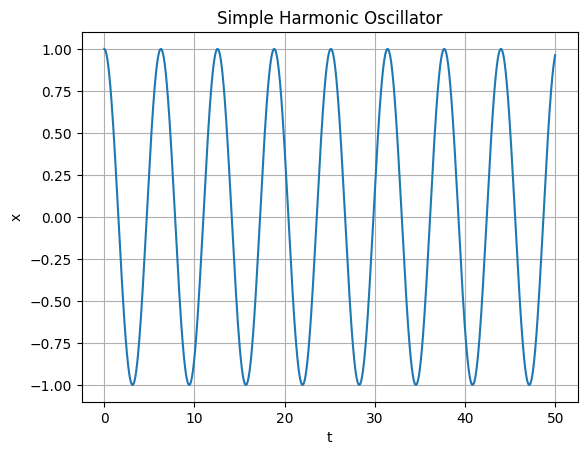

In [112]:
import numpy as np
import matplotlib.pyplot as plt

omega = 1

def f_harm(x,v):
    dxdt = v
    dvdt = -omega**2 * x
    return dxdt, dvdt

def solve_harm(x0=1, v0=0, h=0.01, tmax=50):

    t = np.arange(0,tmax,h)

    x = np.zeros(len(t))
    v = np.zeros(len(t))

    x[0] = x0
    v[0] = v0

    for i in range(len(t)-1):

        k1x, k1v = f_harm(x[i],v[i])

        k2x, k2v = f_harm(x[i]+h*k1x/2, v[i]+h*k1v/2)

        k3x, k3v = f_harm(x[i]+h*k2x/2, v[i]+h*k2v/2)

        k4x, k4v = f_harm(x[i]+h*k3x, v[i]+h*k3v)

        x[i+1] = x[i] + h*(k1x+2*k2x+2*k3x+k4x)/6
        v[i+1] = v[i] + h*(k1v+2*k2v+2*k3v+k4v)/6

    return t,x,v

t,x,v = solve_harm()

plt.plot(t,x)
plt.xlabel("t")
plt.ylabel("x")
plt.grid(which='both', axis='both')
plt.title("Simple Harmonic Oscillator")
plt.show()

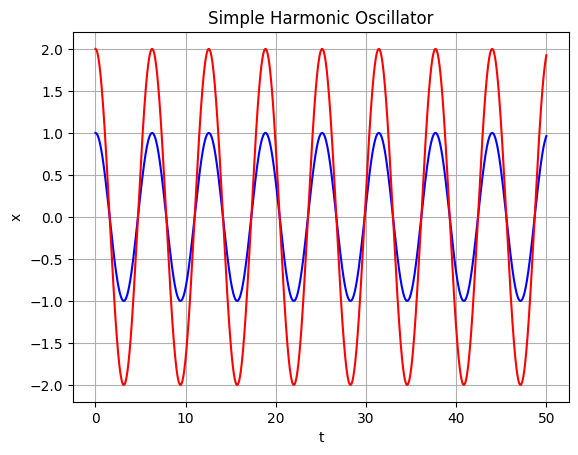

In [113]:
t2,x2,v2 = solve_harm(x0=2)
t1,x1,v1 = solve_harm()

plt.plot(t1,x1, color='blue', label='x=1')
plt.plot(t2,x2, color='red', label='x=2')
plt.xlabel("t")
plt.ylabel("x")
plt.grid(which='both', axis='both')
plt.title("Simple Harmonic Oscillator")
plt.show()

From above plot it is clear that the period of oscillations is pretty much the same.

**Q.4 (c)**

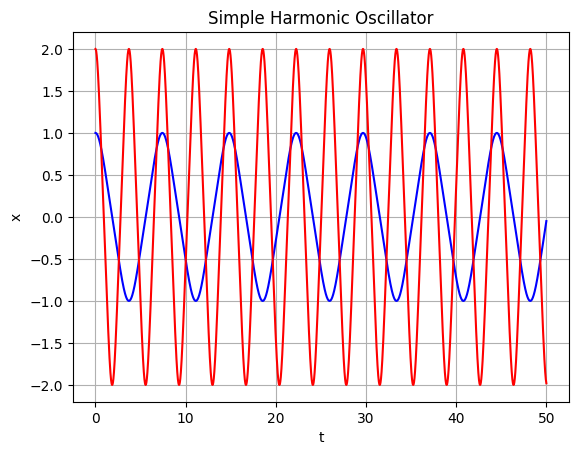

In [114]:
import numpy as np
import matplotlib.pyplot as plt

omega = 1

def f_anharm(x,v):
    dxdt = v
    dvdt = -omega**2 * x**3
    return dxdt, dvdt

def solve_anharm(x0=1, v0=0, h=0.01, tmax=50):

    t = np.arange(0,tmax,h)

    x = np.zeros(len(t))
    v = np.zeros(len(t))

    x[0] = x0
    v[0] = v0

    for i in range(len(t)-1):

        k1x, k1v = f_anharm(x[i],v[i])

        k2x, k2v = f_anharm(x[i]+h*k1x/2, v[i]+h*k1v/2)

        k3x, k3v = f_anharm(x[i]+h*k2x/2, v[i]+h*k2v/2)

        k4x, k4v = f_anharm(x[i]+h*k3x, v[i]+h*k3v)

        x[i+1] = x[i] + h*(k1x+2*k2x+2*k3x+k4x)/6
        v[i+1] = v[i] + h*(k1v+2*k2v+2*k3v+k4v)/6

    return t,x,v

t2,x2,v2 = solve_anharm(x0=2)
t1,x1,v1 = solve_anharm()

plt.plot(t1,x1, color='blue', label='x=1')
plt.plot(t2,x2, color='red', label='x=2')
plt.xlabel("t")
plt.ylabel("x")
plt.grid(which='both', axis='both')
plt.title("Simple Harmonic Oscillator")
plt.show()

It is clear that the time period is less at higher amplitudes.

**Q.4 (d)**

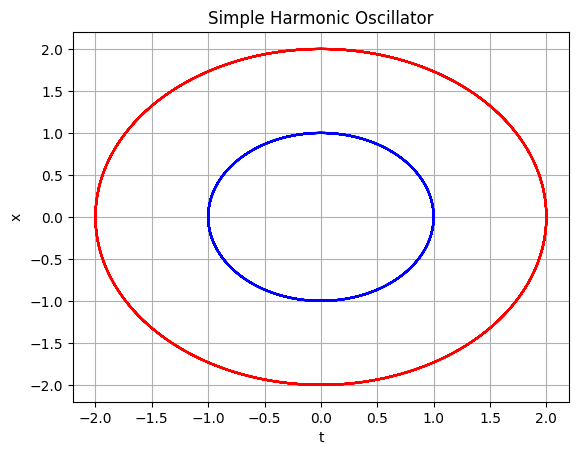

In [115]:
t2,x2,v2 = solve_harm(x0=2)
t1,x1,v1 = solve_harm()

plt.plot(x1,v1, color='blue', label='x=1')
plt.plot(x2,v2, color='red', label='x=2')
plt.xlabel("t")
plt.ylabel("x")
plt.grid(which='both', axis='both')
plt.title("Simple Harmonic Oscillator")
plt.show()

**Q.4 (e)** Writing $\frac{dx}{dt} = v$,

$\frac{dv}{dt} - \mu (1-x^2)v + \omega^2 x=0$

$\therefore \frac{dv}{dt} = \mu (1-x^2)v - \omega^2 x$

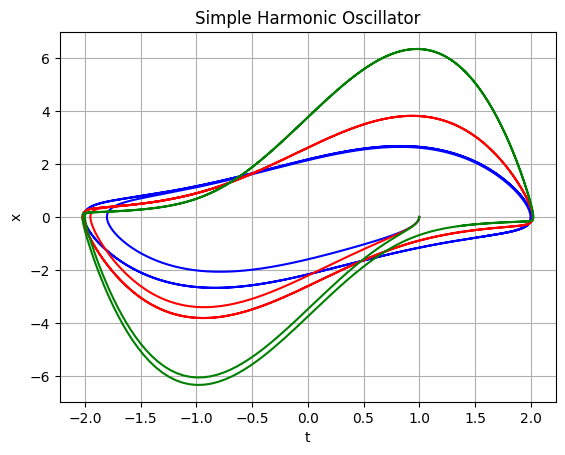

In [116]:
import numpy as np
import matplotlib.pyplot as plt

omega = 1
mu = 2

def f_pol(x,v, mu):
    dxdt = v
    dvdt = mu*(1-x**2)*v -omega**2 * x
    return dxdt, dvdt

def solve_pol(x0=1, v0=0, h=0.01, tmax=20, mu=1):

    t = np.arange(0,tmax,h)

    x = np.zeros(len(t))
    v = np.zeros(len(t))

    x[0] = x0
    v[0] = v0

    for i in range(len(t)-1):

        k1x, k1v = f_pol(x[i],v[i], mu)

        k2x, k2v = f_pol(x[i]+h*k1x/2, v[i]+h*k1v/2, mu)

        k3x, k3v = f_pol(x[i]+h*k2x/2, v[i]+h*k2v/2, mu)

        k4x, k4v = f_pol(x[i]+h*k3x, v[i]+h*k3v, mu)

        x[i+1] = x[i] + h*(k1x+2*k2x+2*k3x+k4x)/6
        v[i+1] = v[i] + h*(k1v+2*k2v+2*k3v+k4v)/6

    return t,x,v

t3,x3,v3 = solve_pol(mu=4)
t2,x2,v2 = solve_pol(mu=2)
t1,x1,v1 = solve_pol()

plt.plot(x1,v1, color='blue', label='x=1')
plt.plot(x2,v2, color='red', label='x=2')
plt.plot(x3,v3, color='green', label='x=3')
plt.xlabel("t")
plt.ylabel("x")
plt.grid(which='both', axis='both')
plt.title("Simple Harmonic Oscillator")
plt.show()

# **Question - 5**

**Q.5 (a)** Writing $\frac{dx}{dt}=v_x,  \frac{dy}{dt}=v_y$ we get

$\frac{dv_x}{dt} = -GM\frac{x}{r^3}$

$\frac{dv_y}{dt} = -GM\frac{y}{r^3}$

Above four equations are first order equation swe can solve.

**Q.5 (b)**

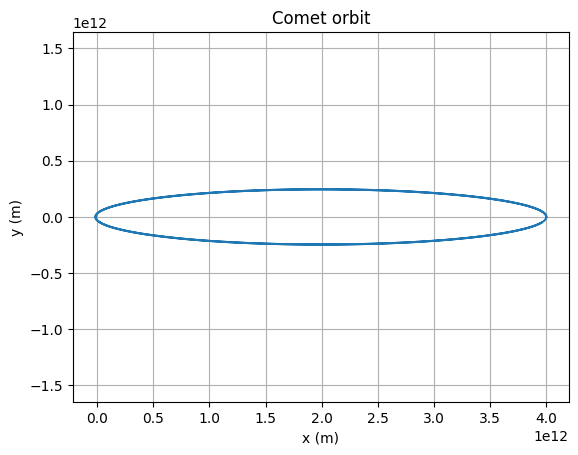

In [117]:
import numpy as np
import matplotlib.pyplot as plt

G = 6.674e-11
M = 1.989e30

def f(x,y,vx,vy):

    r = np.sqrt(x**2 + y**2)

    ax = -G*M*x/r**3
    ay = -G*M*y/r**3

    return vx, vy, ax, ay


def solve(h=10000, tmax=3e9):

    N = int(tmax/h)

    x,y = np.zeros(N),np.zeros(N)
    vx,vy = np.zeros(N),np.zeros(N)

    x[0] = 4e12
    y[0] = 0
    vx[0] = 0
    vy[0] = 500

    for i in range(N-1):

        k1 = f(x[i],y[i],vx[i],vy[i])

        k2 = f(x[i]+h*k1[0]/2,
               y[i]+h*k1[1]/2,
               vx[i]+h*k1[2]/2,
               vy[i]+h*k1[3]/2)

        k3 = f(x[i]+h*k2[0]/2,
               y[i]+h*k2[1]/2,
               vx[i]+h*k2[2]/2,
               vy[i]+h*k2[3]/2)

        k4 = f(x[i]+h*k3[0],
               y[i]+h*k3[1],
               vx[i]+h*k3[2],
               vy[i]+h*k3[3])

        x[i+1] = x[i] + h*(k1[0]+2*k2[0]+2*k3[0]+k4[0])/6
        y[i+1] = y[i] + h*(k1[1]+2*k2[1]+2*k3[1]+k4[1])/6
        vx[i+1] = vx[i] + h*(k1[2]+2*k2[2]+2*k3[2]+k4[2])/6
        vy[i+1] = vy[i] + h*(k1[3]+2*k2[3]+2*k3[3]+k4[3])/6

    return x,y


x,y = solve()

plt.plot(x,y)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Comet orbit")
plt.axis('equal')
plt.grid(which='both',axis='both')
plt.show()

The value of h used was 10000.The simulation shwoed that the trajectory is indeed an ellipse. The integration took long before even near the aphelion, the step size was fixed and very small. this integration took up a large amount of time.

**Q.5 (c)**

/tmp/ipykernel_12383/4002918534.py:60: RuntimeWarning: divide by zero encountered in scalar divide
  rho = (delta*h)/(err*year)


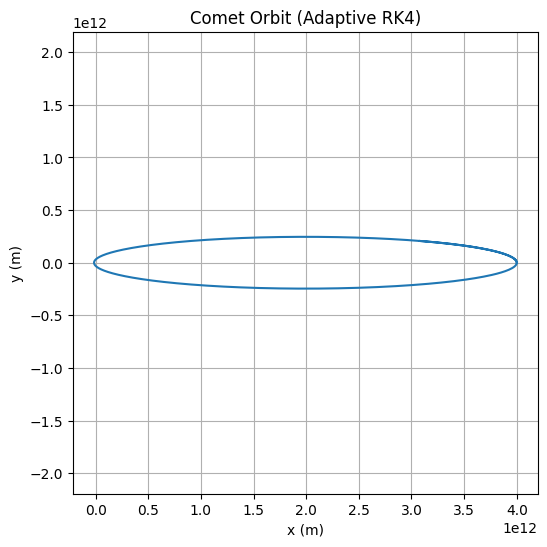

In [118]:
import numpy as np
import matplotlib.pyplot as plt

# constants
G = 6.674e-11
M = 1.989e30

delta = 1000        # target accuracy (meters)
year = 365*24*3600

# derivatives
def f(r):
    x,y,vx,vy = r

    dist = np.sqrt(x*x + y*y)

    ax = -G*M*x/dist**3
    ay = -G*M*y/dist**3

    return np.array([vx,vy,ax,ay])


# RK4 step
def rk4_step(r,h):

    k1 = h*f(r)
    k2 = h*f(r + 0.5*k1)
    k3 = h*f(r + 0.5*k2)
    k4 = h*f(r + k3)

    return r + (k1 + 2*k2 + 2*k3 + k4)/6

r = np.array([
    4e12,
    0.0,
    0.0,
    500.0
])

t = 0
h = 50000

x_list = []
y_list = []

tmax = 2e9

while t < tmax:

    # two small steps
    r1 = rk4_step(r,h)
    r2 = rk4_step(r1,h)

    # one large step
    r_big = rk4_step(r,2*h)

    # error estimate
    err = np.sqrt((r2[0]-r_big[0])**2 + (r2[1]-r_big[1])**2)

    rho = (delta*h)/(err*year)

    if rho > 1:

        # accept step
        r = r2
        t += 2*h

        x_list.append(r[0])
        y_list.append(r[1])

        # adjust step size
        h = h * min(2, rho**0.25)

    else:
        h = h * rho**0.25

plt.figure(figsize=(6,6))
plt.plot(x_list,y_list)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Comet Orbit (Adaptive RK4)")
plt.axis("equal")
plt.grid(which='both',axis='both')
plt.show()

The spepd and accuracy compared to fixed step size is more for the adaptive step size. Here, at the farther regions, we do not need to use a smaller than necessary step size, making the integration faster. The base step size is more than that used in fixed case.

**Q.5 (d)**

/tmp/ipykernel_12383/3845914566.py:60: RuntimeWarning: divide by zero encountered in scalar divide
  rho = (delta*h)/(err*year)


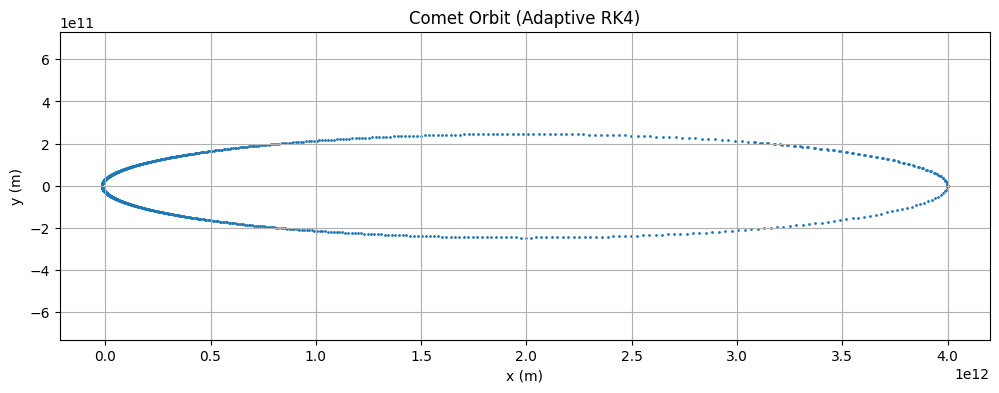

In [119]:
import numpy as np
import matplotlib.pyplot as plt

# constants
G = 6.674e-11
M = 1.989e30

delta = 1000        # target accuracy (meters)
year = 365*24*3600

# derivatives
def f(r):
    x,y,vx,vy = r

    dist = np.sqrt(x*x + y*y)

    ax = -G*M*x/dist**3
    ay = -G*M*y/dist**3

    return np.array([vx,vy,ax,ay])


# RK4 step
def rk4_step(r,h):

    k1 = h*f(r)
    k2 = h*f(r + 0.5*k1)
    k3 = h*f(r + 0.5*k2)
    k4 = h*f(r + k3)

    return r + (k1 + 2*k2 + 2*k3 + k4)/6

r = np.array([
    4e12,
    0.0,
    0.0,
    500.0
])

t = 0
h = 50000

x_list = []
y_list = []

tmax = 2e9

while t < tmax:

    # two small steps
    r1 = rk4_step(r,h)
    r2 = rk4_step(r1,h)

    # one large step
    r_big = rk4_step(r,2*h)

    # error estimate
    err = np.sqrt((r2[0]-r_big[0])**2 + (r2[1]-r_big[1])**2)

    rho = (delta*h)/(err*year)

    if rho > 1:

        # accept step
        r = r2
        t += 2*h

        x_list.append(r[0])
        y_list.append(r[1])

        # adjust step size
        h = h * min(2, rho**0.25)

    else:
        h = h * rho**0.25

plt.figure(figsize=(12,4))
plt.scatter(x_list,y_list, s=1)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Comet Orbit (Adaptive RK4)")
plt.axis("equal")
plt.grid(which='both',axis='both')
plt.show()

# **Question - 6**

**Q.6 (a)**

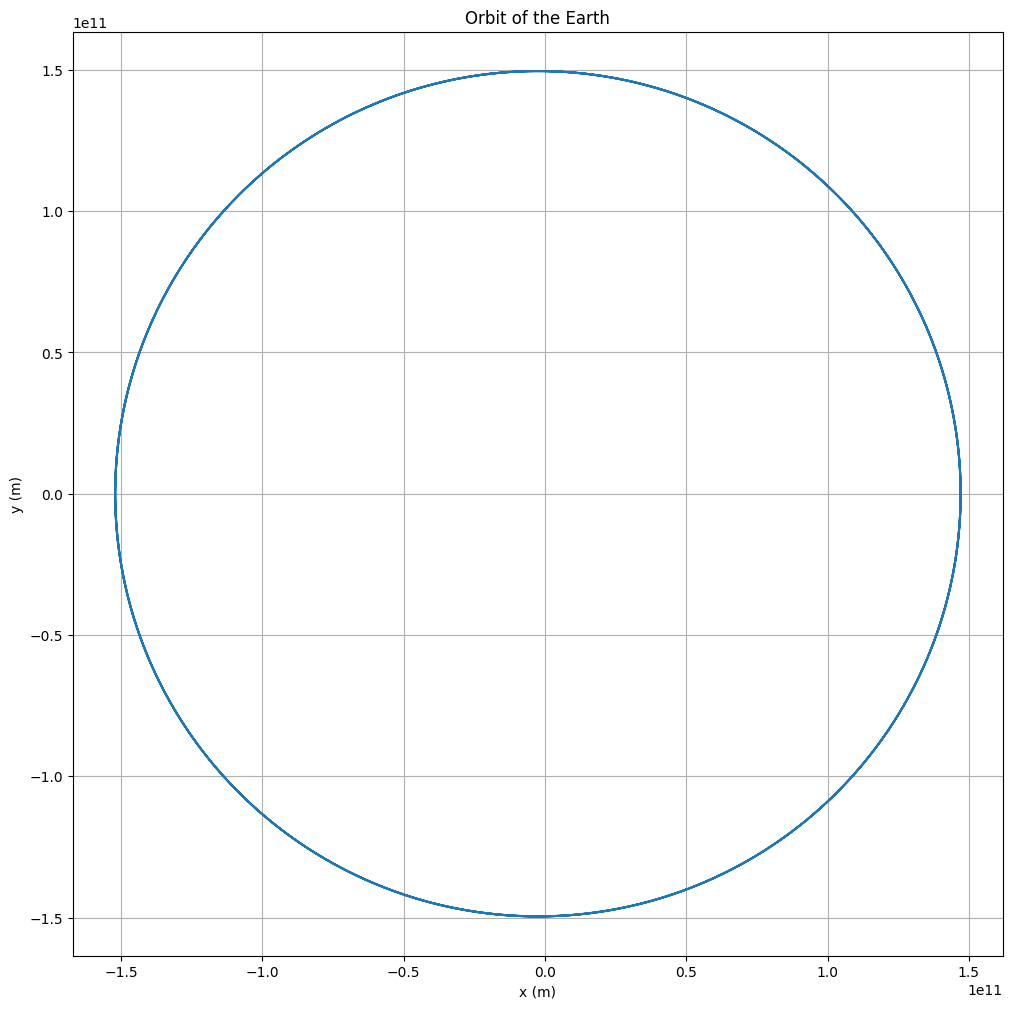

In [120]:
import numpy as np
import matplotlib.pyplot as plt

# constants
G = 6.6738e-11
M = 1.9891e30

h = 3600

tmax = 3*365*24*3600
N = int(tmax/h)

x = np.zeros(N)
y = np.zeros(N)
vx = np.zeros(N)
vy = np.zeros(N)

# initial conditions
x[0] = 1.4710e11
y[0] = 0

vx[0] = 0
vy[0] = 3.0287e4

# initial acceleration
r = np.sqrt(x[0]**2 + y[0]**2)
ax = -G*M*x[0]/r**3
ay = -G*M*y[0]/r**3

for i in range(N-1):

    x[i+1] = x[i] + vx[i]*h + 0.5*ax*h**2
    y[i+1] = y[i] + vy[i]*h + 0.5*ay*h**2

    r_new = np.sqrt(x[i+1]**2 + y[i+1]**2)

    ax_new = -G*M*x[i+1]/r_new**3
    ay_new = -G*M*y[i+1]/r_new**3

    vx[i+1] = vx[i] + 0.5*(ax + ax_new)*h
    vy[i+1] = vy[i] + 0.5*(ay + ay_new)*h

    ax, ay = ax_new, ay_new

plt.figure(figsize=(12,12))
plt.plot(x,y)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Orbit of the Earth")
plt.axis("equal")
plt.grid(which='both',axis='both')
plt.show()

**Q.6 (b)** Run part (a) first

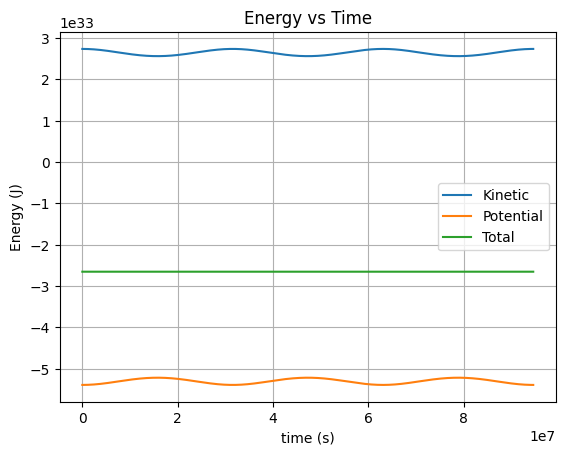

In [121]:
m = 5.9722e24

KE = []
PE = []
TE = []

for i in range(N):

    r = np.sqrt(x[i]**2 + y[i]**2)
    v = np.sqrt(vx[i]**2 + vy[i]**2)

    KE.append(0.5*m*v**2)
    PE.append(-G*M*m/r)
    TE.append(KE[i] + PE[i])

time = np.arange(N)*h

plt.plot(time,KE,label="Kinetic")
plt.plot(time,PE,label="Potential")
plt.plot(time,TE,label="Total")

plt.legend()
plt.xlabel("time (s)")
plt.ylabel("Energy (J)")
plt.grid(which='both', axis='both')
plt.title("Energy vs Time")
plt.show()

**Q.6 (c)**

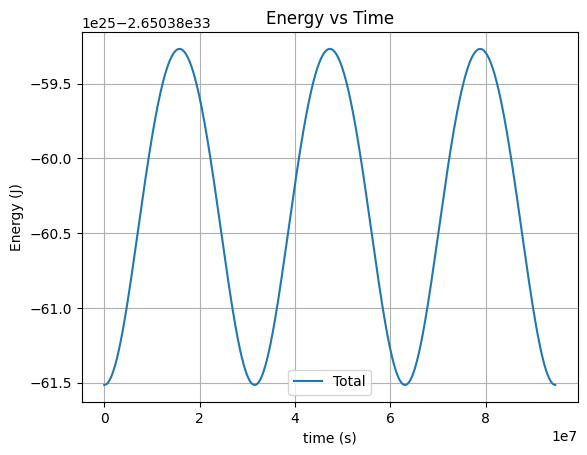

In [122]:
plt.plot(time,TE,label="Total")

plt.legend()
plt.xlabel("time (s)")
plt.ylabel("Energy (J)")
plt.grid(which='both', axis='both')
plt.title("Energy vs Time")
plt.show()

# **Question - 7**

**Q.7 (a)**

In [123]:
import numpy as np
import matplotlib.pyplot as plt

hbar = 1.0545718e-34
me   = 9.10938e-31
eV   = 1.60218e-19

V0 = 50 * eV
a  = 1e-11
m  = me

N    = 1000
x    = np.linspace(-10*a, 10*a, N + 2)
h    = x[1] - x[0]

def V_harmonic(x):
    return V0 * x**2 / a**2

def V_anharmonic(x):
    return V0 * x**4 / a**4

def shoot(E, V_func):
    psi = np.zeros(len(x))
    psi[0] = 0.0
    psi[1] = 1e-10                          # small but non-zero start
    for i in range(1, len(x) - 1):
        k2 = 2*m * (E - V_func(x[i])) / hbar**2
        psi[i+1] = 2*psi[i] - psi[i-1] - h**2 * k2 * psi[i]
        if abs(psi[i+1]) > 1e50:           # prevent overflow
            psi *= 1e-40
    return psi

def find_eigenvalues(V_func, E_min, E_max, n_scan=3000):
    Es   = np.linspace(E_min, E_max, n_scan)
    ends = [shoot(E, V_func)[-1] for E in Es]

    eigenvalues = []
    for i in range(len(ends) - 1):
        if ends[i] * ends[i+1] < 0:        # sign change, bracket
            lo, hi = Es[i], Es[i+1]
            for _ in range(60):             # bisection
                mid = (lo + hi) / 2
                if shoot(lo, V_func)[-1] * shoot(mid, V_func)[-1] < 0:
                    hi = mid
                else:
                    lo = mid
            eigenvalues.append((lo + hi) / 2)
    return eigenvalues

eigs_harm   = find_eigenvalues(V_harmonic,   50*eV, 1000*eV)
harm_eV     = [E/eV for E in eigs_harm[:3]]
hbar_omega  = hbar * np.sqrt(2*V0 / (m * a**2)) / eV   # theoretical spacing

print("Harmonic oscillator")
for n, E in enumerate(harm_eV):
    print(f"  E{n} = {E:.3f} eV")
print(f"  E1-E0 = {harm_eV[1]-harm_eV[0]:.3f} eV")
print(f"  E2-E1 = {harm_eV[2]-harm_eV[1]:.3f} eV")
print(f"  Theory hbar*omega = {hbar_omega:.3f} eV")

Harmonic oscillator
  E0 = 138.020 eV
  E1 = 414.058 eV
  E2 = 690.090 eV
  E1-E0 = 276.038 eV
  E2-E1 = 276.033 eV
  Theory hbar*omega = 276.043 eV


They energy sates appear to be equally spaced.

**Q.7 (b)**

In [124]:
eigs_anharm = find_eigenvalues(V_anharmonic, 50*eV, 2000*eV, n_scan=5000)
anharm_eV   = [E/eV for E in eigs_anharm[:3]]

print("Anharmonic oscillator")
for n, E in enumerate(anharm_eV):
    print(f"  E{n} = {E:.3f} eV")
print(f"  E1-E0 = {anharm_eV[1]-anharm_eV[0]:.3f} eV")
print(f"  E2-E1 = {anharm_eV[2]-anharm_eV[1]:.3f} eV  (unequal → anharmonic)")

Anharmonic oscillator
  E0 = 205.297 eV
  E1 = 735.639 eV
  E2 = 1443.419 eV
  E1-E0 = 530.342 eV
  E2-E1 = 707.780 eV  (unequal → anharmonic)


**Q.7 (c)**

/tmp/ipykernel_12383/283972447.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = 2 * np.trapz(psi[:mid]**2, x[:mid])


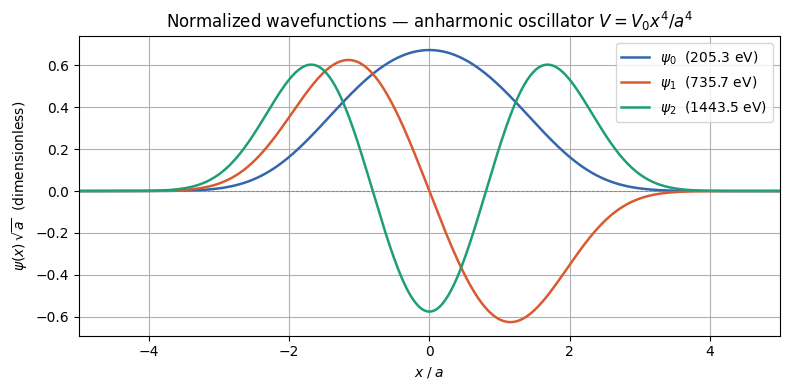

In [125]:
x_plot = (x >= -5*a) & (x <= 5*a)
xp     = x[x_plot]
mid    = len(x) // 2        # using left half only to avoid boundary blow-up

def normalized_psi(E, V_func):
    psi  = shoot(E, V_func)
    # integrate left half only, then double (system is symmetric)
    norm = 2 * np.trapz(psi[:mid]**2, x[:mid])
    return psi / np.sqrt(norm)

colors = ['#3266AD', '#D85A30', '#1D9E75']
labels = [r'$\psi_0$  (205.3 eV)', r'$\psi_1$  (735.7 eV)', r'$\psi_2$  (1443.5 eV)']

fig, ax = plt.subplots(figsize=(8, 4))
for i, E in enumerate(eigs_anharm[:3]):
    psi_norm = normalized_psi(E, V_anharmonic)
    ax.plot(xp/a, psi_norm[x_plot] * np.sqrt(a),   # dimensionless units
            color=colors[i], lw=1.8, label=labels[i])

ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.set_xlabel(r'$x \;/\; a$')
ax.set_ylabel(r'$\psi(x)\,\sqrt{a}$  (dimensionless)')
ax.set_title(r'Normalized wavefunctions — anharmonic oscillator $V = V_0 x^4/a^4$')
ax.legend()
ax.set_xlim(-5, 5)
plt.tight_layout()
plt.savefig('wavefunctions_anharmonic.png', dpi=150)
plt.grid(which='both',axis='both')
plt.show()

The shooting integrator diverges exponentially outside the classically allowed region because any tiny numerical error excites the growing solution. The large values at the right boundary are therefore spurious, not physical

# **Question - 8**

**Q.8 (a)** The gravitational force on $m_1$ due to $m_2$, with separation $\vec{r_2} - \vec{r_1}$ is

$\vec{F} = \frac{Gm_1m_2}{|\vec{r_2} - \vec{r_1} |^3 } (\vec{r_2} - \vec{r_1})$

therefore the equation of motion of all three stars by superposition principle is

$\frac{d^2\vec{r_1}}{dt^2} = \frac{Gm_2}{|\vec{r_2} - \vec{r_1} |^3 } (\vec{r_2} - \vec{r_1}) + \frac{Gm_3}{|\vec{r_3} - \vec{r_1} |^3 } (\vec{r_3} - \vec{r_1})$

similarly for $\vec{r_2}$ and $\vec{r_3}$,

$\frac{d^2\vec{r_2}}{dt^2} = \frac{Gm_1}{|\vec{r_1} - \vec{r_2} |^3 } (\vec{r_1} - \vec{r_2}) + \frac{Gm_3}{|\vec{r_3} - \vec{r_2} |^3 } (\vec{r_3} - \vec{r_2})$

$\frac{d^2\vec{r_3}}{dt^2} = \frac{Gm_1}{|\vec{r_1} - \vec{r_3} |^3 } (\vec{r_1} - \vec{r_3}) + \frac{Gm_2}{|\vec{r_2} - \vec{r_3} |^3 } (\vec{r_2} - \vec{r_3})$

writing $dr_i/dt = v_i$ we have total six equations including

$\frac{d\vec{v_1}}{dt} = \frac{Gm_2}{|\vec{r_2} - \vec{r_1} |^3 } (\vec{r_2} - \vec{r_1}) + \frac{Gm_3}{|\vec{r_3} - \vec{r_1} |^3 } (\vec{r_3} - \vec{r_1})$

$\frac{d\vec{v_2}}{dt} = \frac{Gm_1}{|\vec{r_1} - \vec{r_2} |^3 } (\vec{r_1} - \vec{r_2}) + \frac{Gm_3}{|\vec{r_3} - \vec{r_2} |^3 } (\vec{r_3} - \vec{r_2})$

$\frac{d\vec{v_3}}{dt} = \frac{Gm_1}{|\vec{r_1} - \vec{r_3} |^3 } (\vec{r_1} - \vec{r_3}) + \frac{Gm_2}{|\vec{r_2} - \vec{r_3} |^3 } (\vec{r_2} - \vec{r_3})$

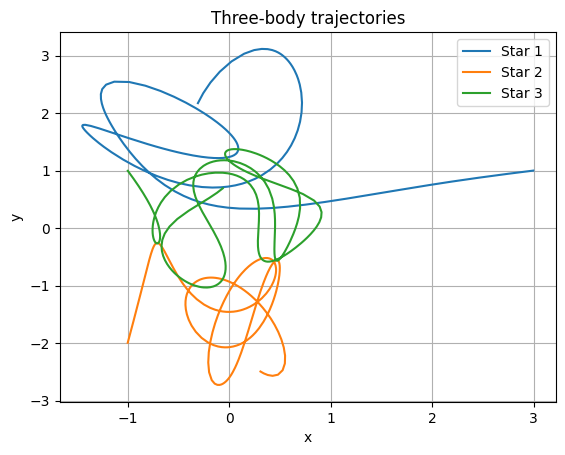

In [126]:
import numpy as np
import matplotlib.pyplot as plt

G = 1

m1,m2,m3 = 150,200,250

# derivatives
def f(r):

    x1,y1,x2,y2,x3,y3,vx1,vy1,vx2,vy2,vx3,vy3 = r

    r12 = np.sqrt((x2-x1)**2 + (y2-y1)**2)
    r13 = np.sqrt((x3-x1)**2 + (y3-y1)**2)
    r23 = np.sqrt((x3-x2)**2 + (y3-y2)**2)

    ax1 = G*m2*(x2-x1)/r12**3 + G*m3*(x3-x1)/r13**3
    ay1 = G*m2*(y2-y1)/r12**3 + G*m3*(y3-y1)/r13**3

    ax2 = G*m1*(x1-x2)/r12**3 + G*m3*(x3-x2)/r23**3
    ay2 = G*m1*(y1-y2)/r12**3 + G*m3*(y3-y2)/r23**3

    ax3 = G*m1*(x1-x3)/r13**3 + G*m2*(x2-x3)/r23**3
    ay3 = G*m1*(y1-y3)/r13**3 + G*m2*(y2-y3)/r23**3

    return np.array([
        vx1,vy1,vx2,vy2,vx3,vy3,
        ax1,ay1,ax2,ay2,ax3,ay3
    ])


def rk4(r,h):

    k1 = h*f(r)
    k2 = h*f(r+0.5*k1)
    k3 = h*f(r+0.5*k2)
    k4 = h*f(r+k3)

    return r + (k1+2*k2+2*k3+k4)/6


# initial state
r = np.array([
    3,1,
    -1,-2,
    -1,1,
    0,0,
    0,0,
    0,0
])

t = 0
tmax = 2
h = 0.01
delta = 1e-3

x1_list,y1_list = [],[]
x2_list,y2_list = [],[]
x3_list,y3_list = [],[]

while t < tmax:

    r1 = rk4(r,h)
    r2 = rk4(r1,h)

    r_big = rk4(r,2*h)

    err = np.linalg.norm(r2[:6]-r_big[:6])

    rho = delta*h/err

    if rho > 1:

        r = r2
        t += 2*h

        x1_list.append(r[0]); y1_list.append(r[1])
        x2_list.append(r[2]); y2_list.append(r[3])
        x3_list.append(r[4]); y3_list.append(r[5])

        h *= min(2,rho**0.25)

    else:
        h *= rho**0.25


plt.plot(x1_list,y1_list,label="Star 1")
plt.plot(x2_list,y2_list,label="Star 2")
plt.plot(x3_list,y3_list,label="Star 3")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Three-body trajectories")
plt.grid(which='both',axis='both')
plt.show()